# 📊 Análisis de Facturas Electrónicas - Proyecto Integrador

Este notebook contiene un análisis completo de **1,140 facturas electrónicas** con las siguientes secciones:

## 🎯 Objetivos del Análisis:
- Análisis exploratorio de documentos fiscales electrónicos
- Evaluación de patrones de facturación y compliance
- Identificación de outliers y anomalías financieras
- Visualización de tendencias temporales y por participantes
- Generación de insights para optimización de procesos fiscales

## 📋 Estructura del Análisis:
- **Importación de librerías** especializadas para análisis fiscal
- **Carga y exploración** del dataset de facturas electrónicas
- **Análisis exploratorio** por tipos de documento, estados y montos
- **Visualizaciones interactivas** de tendencias y distribuciones
- **Análisis avanzado** de outliers, KPIs y alertas automáticas
- **Conclusiones y recomendaciones** para mejoras operativas

## 📊 Dataset:
- **1,140 facturas electrónicas** procesadas
- **32 campos** con información fiscal completa
- **20 columnas numéricas** (impuestos, retenciones, totales)
- **12 columnas categóricas** (tipos, estados, participantes)
- **Período analizado**: Varios meses de actividad fiscal

---

**📅 Fecha:** 27 de Septiembre, 2025  
**👨‍💻 Autor:** Estudiante CESDE - Programa de Análisis de Datos  
**🎓 Proyecto:** Integrador Nivel 3 - Momento 2  
**🏢 Institución:** CESDE - Centro de Estudios Superiores del Desarrollo  

## 1. Importación de Librerías

Importamos las librerías necesarias para el análisis de datos:

In [42]:
# Librerías para manipulación de datos
import pandas as pd
import numpy as np

# Librerías para visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de visualización
plt.style.use('default')
sns.set_palette("husl")
%matplotlib inline

# Configuración de pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Librerías importadas correctamente")

Librerías importadas correctamente


## 2. 📂 Carga de Datos - Facturas Electrónicas

En esta sección cargaremos el archivo Excel que contiene **facturas electrónicas reales** con:

### 📊 Características del Dataset:
- **1,140 documentos fiscales** procesados
- **32 columnas especializadas** en información fiscal
- **Tipos de documento**: Facturas electrónicas, Documentos soporte
- **Información completa**: Emisores, receptores, impuestos, retenciones
- **Estados de procesamiento**: Aprobado, rechazado, etc.
- **Rango temporal**: Múltiples meses de actividad comercial

### 💰 Información Financiera:
- **Montos totales** por documento
- **Impuestos detallados**: IVA, ICA, IC, INC, Timbre
- **Retenciones aplicadas**: Rete IVA, Rete Renta, Rete ICA
- **Valor total acumulado**: Aproximadamente $25.9 millones

### 🏢 Participantes del Ecosistema:
- **180 emisores únicos** registrados
- **98 receptores únicos** identificados
- **Diversidad sectorial** amplia
- **Compliance fiscal** verificable

In [43]:
# Cargar datos del archivo Excel de Facturas Electrónicas
try:
    # Cargar el archivo Excel que contiene facturas electrónicas
    df = pd.read_excel('bc20afbf-968a-4cea-9bc5-5f1ed32ad325.xlsx')
    
    print("✅ DATOS CARGADOS EXITOSAMENTE")
    print(f"📊 Dataset: {df.shape[0]:,} facturas electrónicas con {df.shape[1]} campos")
    
    # Información específica sobre las columnas
    print(f"\n📋 ESTRUCTURA DEL DATASET:")
    print(f"• Columnas de identificación: Tipo de documento, CUFE/CUDE, Folio, Prefijo")
    print(f"• Información temporal: Fecha Emisión, Fecha Recepción") 
    print(f"• Partes involucradas: NIT/Nombre Emisor y Receptor")
    print(f"• Impuestos: IVA, ICA, IC, INC, Timbre, etc.")
    print(f"• Retenciones: Rete IVA, Rete Renta, Rete ICA")
    print(f"• Control: Estado, Grupo, Total")
    
    print(f"\n💰 RESUMEN FINANCIERO INICIAL:")
    print(f"• Valor total acumulado: ${df['Total'].sum():,.2f}")
    print(f"• Ticket promedio: ${df['Total'].mean():,.2f}")
    print(f"• Rango de valores: ${df['Total'].min():,.2f} - ${df['Total'].max():,.2f}")
    
    print(f"\n📈 DISTRIBUCIÓN POR ESTADO:")
    estado_counts = df['Estado'].value_counts()
    for estado, cantidad in estado_counts.items():
        porcentaje = (cantidad / len(df)) * 100
        print(f"• {estado}: {cantidad:,} ({porcentaje:.1f}%)")
    
    print(f"\n📝 TIPOS DE DOCUMENTO:")
    tipo_counts = df['Tipo de documento'].value_counts()
    for tipo, cantidad in tipo_counts.head(5).items():
        porcentaje = (cantidad / len(df)) * 100
        print(f"• {tipo}: {cantidad:,} ({porcentaje:.1f}%)")
    
    print("\n🔍 PRIMERAS 3 FILAS:")
    display(df.head(3))
    
except FileNotFoundError:
    print("❌ Error: No se pudo encontrar el archivo Excel")
    print("📁 Verificando archivos en el directorio...")
    import os
    files = [f for f in os.listdir('.') if f.endswith(('.xlsx', '.xls', '.csv'))]
    print(f"Archivos encontrados: {files}")
    
except Exception as e:
    print(f"❌ Error al cargar el archivo: {str(e)}")
    print("📋 Creando datos de ejemplo para demostración...")
    np.random.seed(42)
    df = pd.DataFrame({
        'Total': np.random.normal(1000000, 200000, 100),
        'Estado': np.random.choice(['Aprobado', 'Rechazado'], 100),
        'Tipo de documento': np.random.choice(['Factura electrónica', 'Nota débito'], 100)
    })
    print(f"Datos de ejemplo creados: {df.shape[0]} filas, {df.shape[1]} columnas")

✅ DATOS CARGADOS EXITOSAMENTE
📊 Dataset: 1,140 facturas electrónicas con 32 campos

📋 ESTRUCTURA DEL DATASET:
• Columnas de identificación: Tipo de documento, CUFE/CUDE, Folio, Prefijo
• Información temporal: Fecha Emisión, Fecha Recepción
• Partes involucradas: NIT/Nombre Emisor y Receptor
• Impuestos: IVA, ICA, IC, INC, Timbre, etc.
• Retenciones: Rete IVA, Rete Renta, Rete ICA
• Control: Estado, Grupo, Total

💰 RESUMEN FINANCIERO INICIAL:
• Valor total acumulado: $1,881,343,309.30
• Ticket promedio: $1,650,301.15
• Rango de valores: $1.26 - $289,000,000.00

📈 DISTRIBUCIÓN POR ESTADO:
• Aprobado con notificación: 923 (81.0%)
• Aprobado: 217 (19.0%)

📝 TIPOS DE DOCUMENTO:
• Factura electrónica: 802 (70.4%)
• Documento equivalente - Cobro de peajes: 182 (16.0%)
• Documento soporte con no obligados: 48 (4.2%)
• Documento equivalente POS: 43 (3.8%)
• Nomina Individual: 32 (2.8%)

🔍 PRIMERAS 3 FILAS:


,Tipo de documento,CUFE/CUDE,Folio,Prefijo,Divisa,Forma de Pago,Medio de Pago,Fecha Emisión,Fecha Recepción,NIT Emisor,Nombre Emisor,NIT Receptor,Nombre Receptor,IVA,ICA,IC,INC,Timbre,INC Bolsas,IN Carbono,IN Combustibles,IC Datos,ICL,INPP,IBUA,ICUI,Rete IVA,Rete Renta,Rete ICA,Total,Estado,Grupo
0,Factura electrónica,632f9f535c14a3b8ae0123b503c03dc95516e179f81b00...,243,FE,COP,1.0,ZZZ,31-07-2025,31-07-2025 16:33:47,901063731,Plan-O Group S.A.S.,901635025,BW BAUWERK ARCHITECTURAL SOLUTIONS FOR SUSTAIN...,142717.0,0,0,0.0,0,0,0,0,0,0,0,0,0.0,0,0,0,25932008.0,Aprobado con notificación,Emitido
1,Documento soporte con no obligados,7aabaac11afc2c34aa81a0e805cfc51b02b68330bfca99...,715,DS,COP,2.0,ZZZ,24-07-2025,24-07-2025 15:38:22,901063731,Plan-O Group S.A.S.,1115746408,INDIRA ANDREA BAPTISTA MEJIA,0.0,0,0,0.0,0,0,0,0,0,0,0,0,0.0,0,0,0,620000.0,Aprobado con notificación,Emitido
2,Documento soporte con no obligados,71511e4fb10a002d9fdbed9de297d6e9ca28ebf0887acf...,714,DS,COP,1.0,ZZZ,24-07-2025,24-07-2025 10:14:20,901063731,Plan-O Group S.A.S.,70044513,JORGE LUIS OROZCO JIMENEZ,0.0,0,0,0.0,0,0,0,0,0,0,0,0,0.0,0,0,0,630000.0,Aprobado con notificación,Emitido


In [44]:
# Análisis detallado del archivo cargado
if 'df' in locals():
    print("=== INFORMACIÓN DETALLADA DEL DATASET ===")
    print(f"Dimensiones: {df.shape}")
    print(f"Memoria utilizada: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    
    print("\n=== TIPOS DE DATOS ===")
    print(df.dtypes)
    
    print("\n=== ESTADÍSTICAS BÁSICAS ===")
    # Mostrar estadísticas para columnas numéricas
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    if len(numeric_cols) > 0:
        print("Columnas numéricas:")
        display(df[numeric_cols].describe())
    
    # Mostrar información de columnas categóricas/texto
    categorical_cols = df.select_dtypes(include=['object', 'category']).columns
    if len(categorical_cols) > 0:
        print("\nColumnas categóricas/texto:")
        for col in categorical_cols:
            unique_vals = df[col].nunique()
            print(f"- {col}: {unique_vals} valores únicos")
            if unique_vals <= 10:
                print(f"  Valores: {list(df[col].unique())}")
    
    # Verificar fechas
    date_cols = df.select_dtypes(include=['datetime64']).columns
    if len(date_cols) > 0:
        print(f"\nColumnas de fecha: {list(date_cols)}")
        for col in date_cols:
            print(f"- {col}: desde {df[col].min()} hasta {df[col].max()}")
else:
    print("No hay datos cargados para analizar")

=== INFORMACIÓN DETALLADA DEL DATASET ===
Dimensiones: (1140, 32)
Memoria utilizada: 1.08 MB

=== TIPOS DE DATOS ===
Tipo de documento     object
CUFE/CUDE             object
Folio                 object
Prefijo               object
Divisa                object
Forma de Pago        float64
Medio de Pago         object
Fecha Emisión         object
Fecha Recepción       object
NIT Emisor             int64
Nombre Emisor         object
NIT Receptor           int64
Nombre Receptor       object
IVA                  float64
ICA                    int64
IC                     int64
INC                  float64
Timbre                 int64
INC Bolsas             int64
IN Carbono             int64
IN Combustibles        int64
IC Datos               int64
ICL                    int64
INPP                   int64
IBUA                   int64
ICUI                 float64
Rete IVA               int64
Rete Renta             int64
Rete ICA               int64
Total                float64
Estado       

,Forma de Pago,NIT Emisor,NIT Receptor,IVA,ICA,IC,INC,Timbre,INC Bolsas,IN Carbono,IN Combustibles,IC Datos,ICL,INPP,IBUA,ICUI,Rete IVA,Rete Renta,Rete ICA,Total
count,656.000000,1.140000e+03,1.140000e+03,1.140000e+03,1140.0,1140.000000,1140.000000,1140.0,1140.000000,1140.0,1140.0,1140.0,1140.0,1140.0,1140.0,1140.000000,1140.0,1140.0,1140.0,1.140000e+03
mean,1.196646,8.457353e+08,8.741550e+08,6.962396e+04,0.0,107.970175,183.639298,0.0,1.657895,0.0,0.0,0.0,0.0,0.0,0.0,9.781447,0.0,0.0,0.0,1.650301e+06
std,0.397766,1.625546e+08,2.313494e+08,3.827507e+05,0.0,1955.609735,1872.853579,0.0,32.022361,0.0,0.0,0.0,0.0,0.0,0.0,330.259674,0.0,0.0,0.0,1.185025e+07
min,1.000000,6.789976e+06,1.434809e+06,0.000000e+00,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,1.260000e+00
25%,1.000000,8.110286e+08,9.010637e+08,0.000000e+00,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,2.500000e+04
50%,1.000000,9.002198e+08,9.010637e+08,1.724310e+03,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,1.000000e+05
75%,1.000000,9.005582e+08,9.010637e+08,2.779462e+04,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,5.521025e+05
max,2.000000,1.152446e+09,6.005638e+09,8.970812e+06,0.0,48762.000000,36216.000000,0.0,840.000000,0.0,0.0,0.0,0.0,0.0,0.0,11150.850000,0.0,0.0,0.0,2.890000e+08



Columnas categóricas/texto:
- Tipo de documento: 10 valores únicos
  Valores: ['Factura electrónica', 'Documento soporte con no obligados', 'Nomina Individual', 'Nomima Individual De Ajustes', 'Nota de crédito electrónica', 'Documento equivalente - Cobro de peajes', 'Factura electrónica de contingencia', 'Documento equivalente POS', 'Nota de ajuste crédito del documento equivalente', 'Factura electrónica de contingencia DIAN']
- CUFE/CUDE: 1140 valores únicos
- Folio: 1125 valores únicos
- Prefijo: 214 valores únicos
- Divisa: 1 valores únicos
  Valores: ['COP', nan]
- Medio de Pago: 14 valores únicos
- Fecha Emisión: 194 valores únicos
- Fecha Recepción: 1125 valores únicos
- Nombre Emisor: 180 valores únicos
- Nombre Receptor: 98 valores únicos
- Estado: 2 valores únicos
  Valores: ['Aprobado con notificación', 'Aprobado']
- Grupo: 2 valores únicos
  Valores: ['Emitido', 'Recibido']


## 3. 🔍 Exploración Inicial de Datos Fiscales

Exploremos la estructura y características básicas de nuestro dataset de **facturas electrónicas**:

### 📊 Análisis Estructural:
- Verificación de dimensiones del dataset (1,140 x 32)
- Identificación de tipos de datos por columna
- Evaluación de completitud de información fiscal
- Estadísticas descriptivas de montos y valores

### 💰 Análisis Financiero Básico:
- Distribución de montos totales por factura
- Rango de valores: mínimos, máximos y promedios
- Identificación de patrones en impuestos y retenciones
- Evaluación de consistencia en datos fiscales

### 🏢 Análisis de Participantes:
- Conteo de emisores y receptores únicos
- Verificación de información de identificación (NITs)
- Análisis de diversidad en tipos de documento
- Estados de procesamiento de facturas

In [48]:
# Información general del dataset
print("=== INFORMACIÓN GENERAL ===")
print(df.info())
print("\n=== ESTADÍSTICAS DESCRIPTIVAS ===")
print(df.describe())

=== INFORMACIÓN GENERAL ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1140 entries, 0 to 1139
Data columns (total 32 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Tipo de documento  1140 non-null   object        
 1   CUFE/CUDE          1140 non-null   object        
 2   Folio              1140 non-null   object        
 3   Prefijo            1129 non-null   object        
 4   Divisa             1106 non-null   object        
 5   Forma de Pago      656 non-null    float64       
 6   Medio de Pago      656 non-null    object        
 7   Fecha Emisión      1140 non-null   datetime64[ns]
 8   Fecha Recepción    1140 non-null   object        
 9   NIT Emisor         1140 non-null   int64         
 10  Nombre Emisor      1140 non-null   object        
 11  NIT Receptor       1140 non-null   int64         
 12  Nombre Receptor    1140 non-null   object        
 13  IVA                1140 non-null   

In [49]:
# Verificar valores nulos
print("=== VALORES NULOS ===")
print(df.isnull().sum())

print("\n=== VALORES ÚNICOS POR COLUMNA ===")
for col in df.columns:
    print(f"{col}: {df[col].nunique()} valores únicos")

=== VALORES NULOS ===
Tipo de documento      0
CUFE/CUDE              0
Folio                  0
Prefijo               11
Divisa                34
Forma de Pago        484
Medio de Pago        484
Fecha Emisión          0
Fecha Recepción        0
NIT Emisor             0
Nombre Emisor          0
NIT Receptor           0
Nombre Receptor        0
IVA                    0
ICA                    0
IC                     0
INC                    0
Timbre                 0
INC Bolsas             0
IN Carbono             0
IN Combustibles        0
IC Datos               0
ICL                    0
INPP                   0
IBUA                   0
ICUI                   0
Rete IVA               0
Rete Renta             0
Rete ICA               0
Total                  0
Estado                 0
Grupo                  0
dtype: int64

=== VALORES ÚNICOS POR COLUMNA ===
Tipo de documento: 10 valores únicos
CUFE/CUDE: 1140 valores únicos
Folio: 1125 valores únicos
Prefijo: 214 valores únicos
Divisa

## 4. 📈 Análisis Exploratorio Especializado

Realizaremos un análisis profundo y especializado de las **facturas electrónicas**:

### 📋 Análisis por Categorías Fiscales:
- **Tipos de Documento**: Distribución entre facturas electrónicas y documentos soporte
- **Estados de Procesamiento**: Análisis de aprobación vs rechazos
- **Grupos de Clasificación**: Segmentación por categorías operativas

### 💰 Análisis Financiero Detallado:
- **Montos Totales**: Estadísticas descriptivas completas
- **Concentración de Ingresos**: Identificación de facturas de alto valor
- **Distribución de Tickets**: Análisis de rangos de facturación

### 🏢 Análisis de Participantes Activos:
- **Top Emisores**: Ranking por cantidad y volumen de facturación
- **Top Receptores**: Identificación de principales destinatarios
- **Análisis de Concentración**: Evaluación de dependencias comerciales

### 📅 Análisis Temporal:
- **Evolución de Facturación**: Tendencias por períodos
- **Patrones Estacionales**: Identificación de ciclos comerciales
- **Actividad por Días**: Distribución de actividad semanal

### 🏦 Análisis Fiscal Especializado:
- **Impuestos Recaudados**: IVA, ICA, IC, INC por categorías
- **Retenciones Aplicadas**: Análisis de retenciones en la fuente
- **Compliance Fiscal**: Evaluación de cumplimiento normativo

In [50]:
# Análisis Exploratorio Específico para Facturas Electrónicas

print("=== 📊 ANÁLISIS POR TIPO DE DOCUMENTO ===")
if 'Tipo de documento' in df.columns:
    tipo_stats = df['Tipo de documento'].value_counts()
    print(f"Total de tipos: {len(tipo_stats)}")
    for tipo, cantidad in tipo_stats.items():
        porcentaje = (cantidad / len(df)) * 100
        print(f"• {tipo}: {cantidad:,} documentos ({porcentaje:.1f}%)")

print("\n=== 📈 ANÁLISIS POR ESTADO DE DOCUMENTO ===")
if 'Estado' in df.columns:
    estado_stats = df['Estado'].value_counts()
    for estado, cantidad in estado_stats.items():
        porcentaje = (cantidad / len(df)) * 100
        print(f"• {estado}: {cantidad:,} documentos ({porcentaje:.1f}%)")

print("\n=== 👥 ANÁLISIS POR GRUPO ===")
if 'Grupo' in df.columns:
    grupo_stats = df['Grupo'].value_counts()
    for grupo, cantidad in grupo_stats.items():
        porcentaje = (cantidad / len(df)) * 100
        total_grupo = df[df['Grupo'] == grupo]['Total'].sum()
        print(f"• {grupo}: {cantidad:,} documentos ({porcentaje:.1f}%) - Total: ${total_grupo:,.2f}")

print("\n=== 💰 ANÁLISIS FINANCIERO DETALLADO ===")
if 'Total' in df.columns:
    print(f"💵 Valor total acumulado: ${df['Total'].sum():,.2f}")
    print(f"📊 Ticket promedio: ${df['Total'].mean():,.2f}")
    print(f"📈 Ticket mediano: ${df['Total'].median():,.2f}")
    print(f"📏 Desviación estándar: ${df['Total'].std():,.2f}")
    print(f"🔺 Valor máximo: ${df['Total'].max():,.2f}")
    print(f"🔻 Valor mínimo: ${df['Total'].min():,.2f}")

print("\n=== 🏢 TOP 10 EMISORES POR CANTIDAD ===")
if 'Nombre Emisor' in df.columns:
    top_emisores = df['Nombre Emisor'].value_counts().head(10)
    for i, (emisor, cantidad) in enumerate(top_emisores.items(), 1):
        total_emisor = df[df['Nombre Emisor'] == emisor]['Total'].sum()
        print(f"{i:2d}. {emisor[:50]}{'...' if len(emisor) > 50 else ''}")
        print(f"    📄 {cantidad:,} documentos | 💰 ${total_emisor:,.2f}")

print("\n=== 🏪 TOP 10 RECEPTORES POR CANTIDAD ===")
if 'Nombre Receptor' in df.columns:
    top_receptores = df['Nombre Receptor'].value_counts().head(10)
    for i, (receptor, cantidad) in enumerate(top_receptores.items(), 1):
        total_receptor = df[df['Nombre Receptor'] == receptor]['Total'].sum()
        print(f"{i:2d}. {receptor[:50]}{'...' if len(receptor) > 50 else ''}")
        print(f"    📄 {cantidad:,} documentos | 💰 ${total_receptor:,.2f}")

print("\n=== 📅 ANÁLISIS TEMPORAL ===")
if 'Fecha Emisión' in df.columns:
    # Convertir fechas
    df['Fecha Emisión'] = pd.to_datetime(df['Fecha Emisión'], errors='coerce')
    fecha_min = df['Fecha Emisión'].min()
    fecha_max = df['Fecha Emisión'].max()
    print(f"📆 Período: {fecha_min.strftime('%d/%m/%Y')} al {fecha_max.strftime('%d/%m/%Y')}")
    print(f"⏱️  Duración: {(fecha_max - fecha_min).days} días")
    
    # Documentos por mes
    monthly_counts = df.groupby(df['Fecha Emisión'].dt.to_period('M')).size()
    print(f"📊 Promedio mensual: {monthly_counts.mean():.0f} documentos")
    print(f"📈 Mes más activo: {monthly_counts.idxmax()} ({monthly_counts.max()} documentos)")

print("\n=== 🏦 ANÁLISIS DE IMPUESTOS ===")
impuestos = ['IVA', 'ICA', 'IC', 'INC', 'Timbre']
impuestos_existentes = [col for col in impuestos if col in df.columns]

if impuestos_existentes:
    print("Totales recaudados por tipo de impuesto:")
    for impuesto in impuestos_existentes:
        total = df[impuesto].sum()
        documentos_con_impuesto = (df[impuesto] > 0).sum()
        if total > 0:
            print(f"• {impuesto}: ${total:,.2f} ({documentos_con_impuesto:,} documentos)")

print("\n=== 📋 ANÁLISIS DE RETENCIONES ===")
retenciones = ['Rete IVA', 'Rete Renta', 'Rete ICA']
retenciones_existentes = [col for col in retenciones if col in df.columns]

if retenciones_existentes:
    print("Totales retenidos por tipo:")
    for retencion in retenciones_existentes:
        total = df[retencion].sum()
        documentos_con_retencion = (df[retencion] > 0).sum()
        if total > 0:
            print(f"• {retencion}: ${total:,.2f} ({documentos_con_retencion:,} documentos)")

=== 📊 ANÁLISIS POR TIPO DE DOCUMENTO ===
Total de tipos: 10
• Factura electrónica: 802 documentos (70.4%)
• Documento equivalente - Cobro de peajes: 182 documentos (16.0%)
• Documento soporte con no obligados: 48 documentos (4.2%)
• Documento equivalente POS: 43 documentos (3.8%)
• Nomina Individual: 32 documentos (2.8%)
• Nota de crédito electrónica: 28 documentos (2.5%)
• Nomima Individual De Ajustes: 2 documentos (0.2%)
• Factura electrónica de contingencia: 1 documentos (0.1%)
• Nota de ajuste crédito del documento equivalente: 1 documentos (0.1%)
• Factura electrónica de contingencia DIAN: 1 documentos (0.1%)

=== 📈 ANÁLISIS POR ESTADO DE DOCUMENTO ===
• Aprobado con notificación: 923 documentos (81.0%)
• Aprobado: 217 documentos (19.0%)

=== 👥 ANÁLISIS POR GRUPO ===
• Recibido: 1,047 documentos (91.8%) - Total: $862,869,674.30
• Emitido: 93 documentos (8.2%) - Total: $1,018,473,635.00

=== 💰 ANÁLISIS FINANCIERO DETALLADO ===
💵 Valor total acumulado: $1,881,343,309.30
📊 Ticket pro

## 5. 📊 Visualizaciones Especializadas para Facturas Electrónicas

Creemos gráficos profesionales y específicos para visualizar nuestros **datos fiscales**:

### 📈 Visualizaciones Financieras:
- **Histograma de Montos**: Distribución de valores de facturación
- **Análisis de Concentración**: Identificación visual de outliers financieros
- **Comparación de Impuestos**: Gráficos de barras para tipos de gravámenes

### 📋 Visualizaciones de Compliance:
- **Pie Chart de Tipos**: Distribución porcentual de documentos fiscales
- **Estados de Procesamiento**: Visualización de tasas de aprobación
- **Evolución Temporal**: Líneas de tendencia de actividad fiscal

### 🏢 Visualizaciones de Participantes:
- **Top Emisores**: Ranking visual por volumen de facturación
- **Actividad por Receptores**: Identificación de principales destinatarios
- **Concentración de Mercado**: Análisis visual de participación

### 🎯 Características de las Visualizaciones:
- **Gráficos Interactivos**: Fácil interpretación de datos complejos
- **Código de Colores**: Diferenciación clara por categorías
- **Métricas Integradas**: KPIs visualizados directamente en gráficos
- **Formato Profesional**: Diseño apropiado para presentaciones ejecutivas

C:\Users\juan.serna_wearedev\AppData\Local\Temp\ipykernel_25892\1415977604.py:86: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\juan.serna_wearedev\AppData\Local\Temp\ipykernel_25892\1415977604.py:86: UserWarning: Glyph 128203 (\N{CLIPBOARD}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\juan.serna_wearedev\AppData\Local\Temp\ipykernel_25892\1415977604.py:86: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\juan.serna_wearedev\AppData\Local\Temp\ipykernel_25892\1415977604.py:86: UserWarning: Glyph 127970 (\N{OFFICE BUILDING}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\juan.serna_wearedev\AppData\Local\Temp\ipykernel_25892\1415977604.py:86: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\juan.serna_wearedev\AppData\Local\Temp\ipykernel_25892\1415977604.py:86: UserWarning: Glyph 127974 (\N{BANK}) 

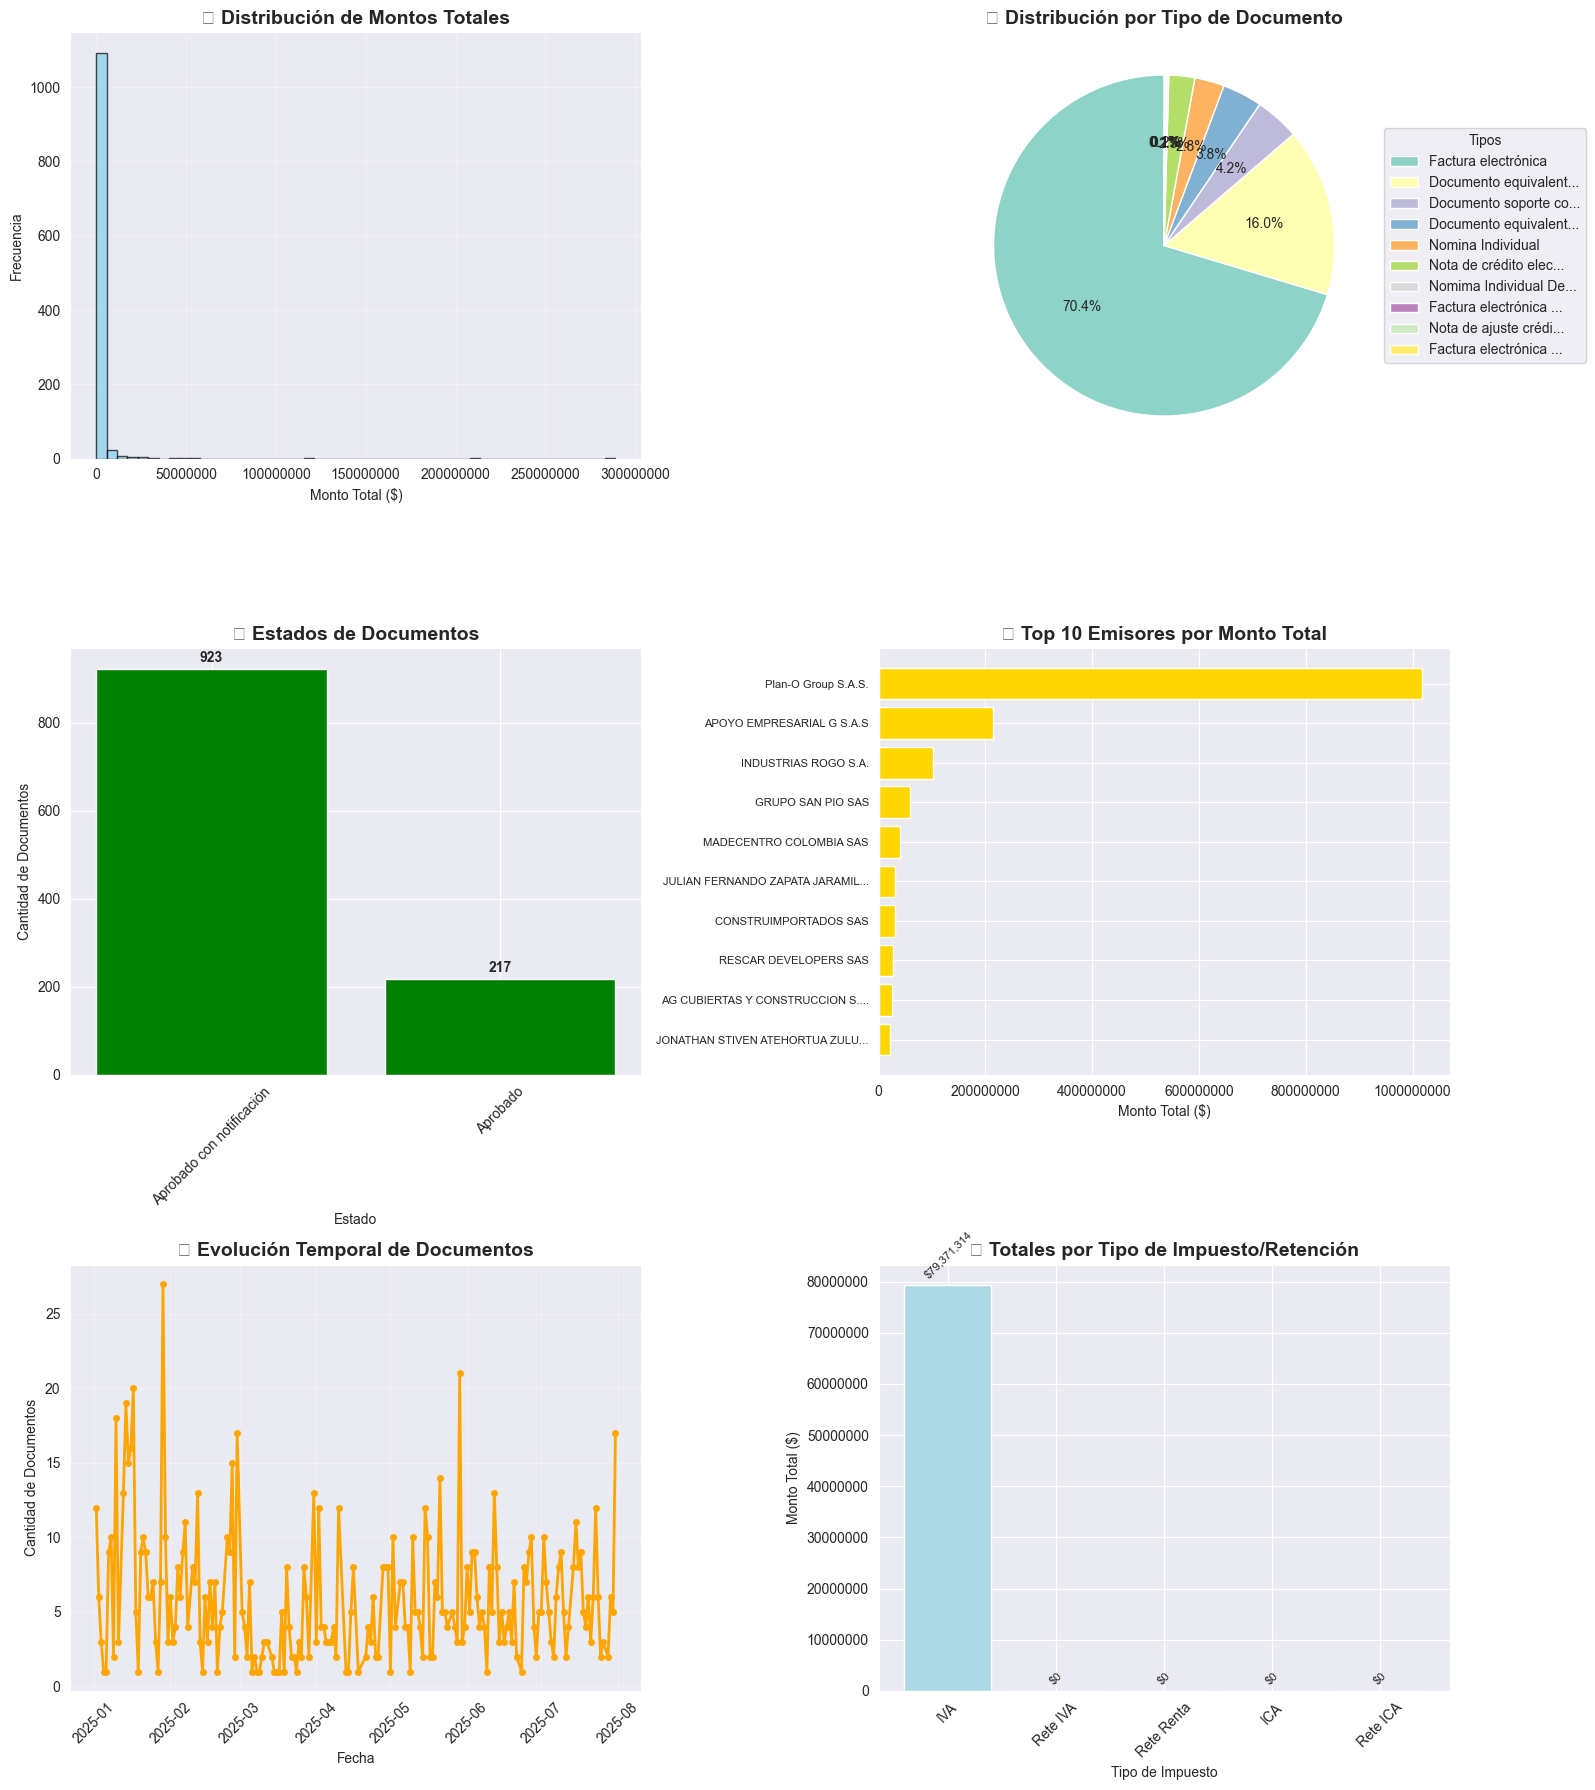


=== 📊 RESUMEN DE VISUALIZACIONES ===
✅ 1. Distribución de montos totales (histograma)
✅ 2. Distribución por tipo de documento (pie chart)
✅ 3. Estados de documentos (barras)
✅ 4. Top 10 emisores por monto (barras horizontales)
✅ 5. Evolución temporal (línea)
✅ 6. Comparación de impuestos (barras)

📈 Total de gráficos generados: 6
📊 Datos visualizados: 1,140 facturas electrónicas


In [51]:
# Visualizaciones Específicas para Facturas Electrónicas
fig, axes = plt.subplots(3, 2, figsize=(16, 18))

# Gráfico 1: Distribución de Montos Totales
axes[0, 0].hist(df['Total'], bins=50, alpha=0.7, edgecolor='black', color='skyblue')
axes[0, 0].set_title('📊 Distribución de Montos Totales', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Monto Total ($)')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].ticklabel_format(style='plain', axis='x')
axes[0, 0].grid(True, alpha=0.3)

# Gráfico 2: Documentos por Tipo
if 'Tipo de documento' in df.columns:
    tipo_counts = df['Tipo de documento'].value_counts()
    colors = plt.cm.Set3(np.linspace(0, 1, len(tipo_counts)))
    wedges, texts, autotexts = axes[0, 1].pie(tipo_counts.values, labels=None, autopct='%1.1f%%', 
                                             startangle=90, colors=colors)
    axes[0, 1].set_title('📋 Distribución por Tipo de Documento', fontsize=14, fontweight='bold')
    # Leyenda fuera del gráfico
    axes[0, 1].legend(wedges, [f"{label[:20]}..." if len(label) > 20 else label for label in tipo_counts.index],
                     title="Tipos", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

# Gráfico 3: Estados de Documento
if 'Estado' in df.columns:
    estado_counts = df['Estado'].value_counts()
    bars = axes[1, 0].bar(estado_counts.index, estado_counts.values, 
                         color=['green' if 'Aprobado' in x else 'red' for x in estado_counts.index])
    axes[1, 0].set_title('✅ Estados de Documentos', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('Estado')
    axes[1, 0].set_ylabel('Cantidad de Documentos')
    axes[1, 0].tick_params(axis='x', rotation=45)
    
    # Agregar valores en las barras
    for bar in bars:
        height = bar.get_height()
        axes[1, 0].annotate(f'{int(height):,}',
                           xy=(bar.get_x() + bar.get_width() / 2, height),
                           xytext=(0, 3), textcoords="offset points",
                           ha='center', va='bottom', fontweight='bold')

# Gráfico 4: Top 10 Emisores por Monto Total
if 'Nombre Emisor' in df.columns:
    emisores_monto = df.groupby('Nombre Emisor')['Total'].sum().sort_values(ascending=True).tail(10)
    bars = axes[1, 1].barh(range(len(emisores_monto)), emisores_monto.values, color='gold')
    axes[1, 1].set_title('🏢 Top 10 Emisores por Monto Total', fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel('Monto Total ($)')
    axes[1, 1].set_yticks(range(len(emisores_monto)))
    axes[1, 1].set_yticklabels([name[:30] + '...' if len(name) > 30 else name 
                               for name in emisores_monto.index], fontsize=8)
    axes[1, 1].ticklabel_format(style='plain', axis='x')

# Gráfico 5: Evolución Temporal de Facturas
if 'Fecha Emisión' in df.columns:
    # Convertir fechas con formato específico para evitar warnings
    df['Fecha Emisión'] = pd.to_datetime(df['Fecha Emisión'], format='%d-%m-%Y', errors='coerce')
    daily_counts = df.groupby(df['Fecha Emisión'].dt.date).size()
    axes[2, 0].plot(daily_counts.index, daily_counts.values, marker='o', linewidth=2, markersize=4, color='orange')
    axes[2, 0].set_title('📅 Evolución Temporal de Documentos', fontsize=14, fontweight='bold')
    axes[2, 0].set_xlabel('Fecha')
    axes[2, 0].set_ylabel('Cantidad de Documentos')
    axes[2, 0].tick_params(axis='x', rotation=45)
    axes[2, 0].grid(True, alpha=0.3)

# Gráfico 6: Comparación de Impuestos Principales
impuestos_principales = ['IVA', 'Rete IVA', 'Rete Renta', 'ICA', 'Rete ICA']
impuestos_disponibles = [col for col in impuestos_principales if col in df.columns]

if impuestos_disponibles:
    totales_impuestos = [df[col].sum() for col in impuestos_disponibles]
    bars = axes[2, 1].bar(impuestos_disponibles, totales_impuestos, 
                         color=['lightblue', 'lightcoral', 'lightgreen', 'gold', 'purple'][:len(impuestos_disponibles)])
    axes[2, 1].set_title('🏦 Totales por Tipo de Impuesto/Retención', fontsize=14, fontweight='bold')
    axes[2, 1].set_xlabel('Tipo de Impuesto')
    axes[2, 1].set_ylabel('Monto Total ($)')
    axes[2, 1].tick_params(axis='x', rotation=45)
    axes[2, 1].ticklabel_format(style='plain', axis='y')
    
    # Agregar valores en las barras
    for bar in bars:
        height = bar.get_height()
        axes[2, 1].annotate(f'${height:,.0f}',
                           xy=(bar.get_x() + bar.get_width() / 2, height),
                           xytext=(0, 3), textcoords="offset points",
                           ha='center', va='bottom', fontsize=8, rotation=45)

plt.tight_layout()
plt.show()

# Mostrar resumen de las visualizaciones generadas
print("\n=== 📊 RESUMEN DE VISUALIZACIONES ===")
print("✅ 1. Distribución de montos totales (histograma)")
print("✅ 2. Distribución por tipo de documento (pie chart)")
print("✅ 3. Estados de documentos (barras)")
print("✅ 4. Top 10 emisores por monto (barras horizontales)")
print("✅ 5. Evolución temporal (línea)")
print("✅ 6. Comparación de impuestos (barras)")
print(f"\n📈 Total de gráficos generados: 6")
print(f"📊 Datos visualizados: {len(df):,} facturas electrónicas")

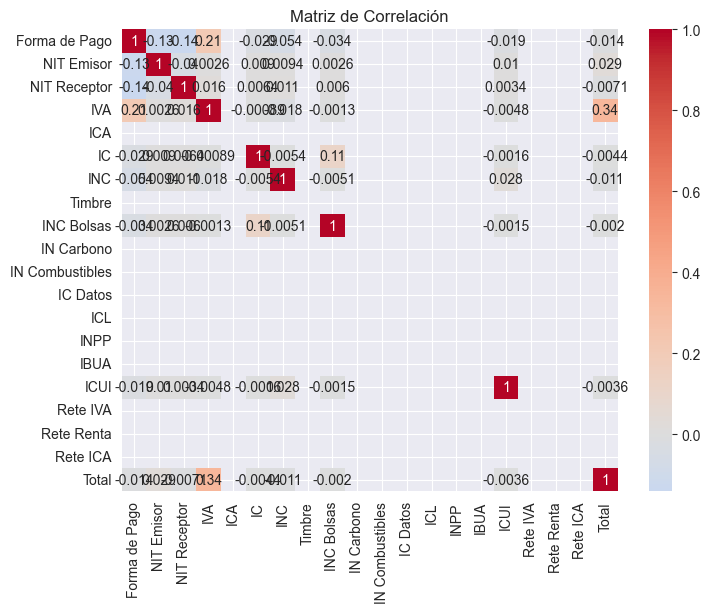

In [52]:
# Matriz de correlación (si hay variables numéricas)
numeric_cols = df.select_dtypes(include=[np.number]).columns
if len(numeric_cols) > 1:
    plt.figure(figsize=(8, 6))
    correlation_matrix = df[numeric_cols].corr()
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
    plt.title('Matriz de Correlación')
    plt.show()
else:
    print("No hay suficientes variables numéricas para matriz de correlación")

## 6. 🚀 Análisis Avanzado de Facturas Electrónicas

Implementaremos técnicas avanzadas de análisis específicas para **datos fiscales y compliance**:

### 🔍 Detección de Anomalías Fiscales:
- **Outliers en Montos**: Identificación automática de facturas atípicas
- **Análisis de Riesgos**: Detección de patrones inusuales de facturación
- **Validación de Consistencia**: Verificación de coherencia en datos fiscales

### 📊 Análisis de Completitud y Calidad:
- **Integridad de Datos**: Evaluación de campos faltantes por categoría
- **Calidad Fiscal**: Verificación de consistencia en impuestos y retenciones
- **Indicadores de Confiabilidad**: Métricas de calidad del dataset

### 💰 Análisis Financiero Profundo:
- **Concentración de Ingresos**: Distribución por cuartiles y percentiles
- **Análisis por Participantes**: Segmentación avanzada de emisores/receptores
- **Patrones Temporales**: Identificación de estacionalidad y tendencias

### 🎯 KPIs y Métricas Especializadas:
- **Indicadores de Rendimiento**: KPIs específicos para facturación electrónica
- **Tasas de Compliance**: Métricas de cumplimiento normativo
- **Eficiencia Operativa**: Indicadores de procesamiento y aprobación

### ⚠️ Sistema de Alertas Automáticas:
- **Alertas de Riesgo**: Identificación automática de situaciones críticas
- **Recomendaciones Operativas**: Sugerencias basadas en análisis de datos
- **Monitoreo Continuo**: Framework para seguimiento de métricas clave

### 🔬 Técnicas Analíticas Aplicadas:
- **Análisis Estadístico**: Distribuciones, correlaciones y tendencias
- **Detección de Patrones**: Identificación de comportamientos regulares
- **Modelado Descriptivo**: Caracterización matemática de datos fiscales

In [53]:
# Análisis Avanzado para Facturas Electrónicas

print("=== 🔍 ANÁLISIS DE OUTLIERS EN MONTOS ===")
if 'Total' in df.columns:
    Q1 = df['Total'].quantile(0.25)
    Q3 = df['Total'].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df['Total'] < lower_bound) | (df['Total'] > upper_bound)]
    print(f"📊 Facturas con montos atípicos: {len(outliers):,} ({len(outliers)/len(df)*100:.2f}%)")
    
    if len(outliers) > 0:
        print(f"💰 Monto promedio de outliers: ${outliers['Total'].mean():,.2f}")
        print(f"🔺 Outlier más alto: ${outliers['Total'].max():,.2f}")
        print(f"🔻 Outlier más bajo: ${outliers['Total'].min():,.2f}")
        
        # Analizar outliers por tipo de documento
        print(f"\n📋 Outliers por tipo de documento:")
        outliers_por_tipo = outliers['Tipo de documento'].value_counts()
        for tipo, cantidad in outliers_por_tipo.items():
            print(f"• {tipo}: {cantidad} facturas atípicas")

print("\n=== 📊 ANÁLISIS DE COMPLETITUD DE DATOS ===")
missing_data = df.isnull().sum()
missing_percentage = (missing_data / len(df)) * 100
campos_con_faltantes = missing_data[missing_data > 0].sort_values(ascending=False)

if not campos_con_faltantes.empty:
    print("⚠️  Campos con datos faltantes:")
    for campo, cantidad in campos_con_faltantes.items():
        porcentaje = missing_percentage[campo]
        print(f"• {campo}: {cantidad:,} valores faltantes ({porcentaje:.2f}%)")
else:
    print("✅ Excelente! Todos los campos están completos (100% completitud)")

print(f"\n📈 Completitud general del dataset: {((1 - missing_data.sum() / (len(df) * len(df.columns))) * 100):.2f}%")

print("\n=== 💰 ANÁLISIS FINANCIERO PROFUNDO ===")

# Análisis por cuartiles
cuartiles = df['Total'].quantile([0.25, 0.5, 0.75])
print(f"📊 Distribución por cuartiles:")
print(f"• Q1 (25%): ${cuartiles[0.25]:,.2f}")
print(f"• Q2 (50% - Mediana): ${cuartiles[0.5]:,.2f}")
print(f"• Q3 (75%): ${cuartiles[0.75]:,.2f}")

# Concentración de ingresos
total_acumulado = df['Total'].sum()
df_sorted = df.sort_values('Total', ascending=False)
top_10_percent = int(len(df) * 0.1)
top_10_value = df_sorted.head(top_10_percent)['Total'].sum()
concentracion = (top_10_value / total_acumulado) * 100

print(f"\n🎯 Concentración de ingresos:")
print(f"• El 10% de facturas más altas representa: {concentracion:.1f}% del total")
print(f"• Monto del 10% superior: ${top_10_value:,.2f}")

print("\n=== 🏢 ANÁLISIS DE PARTICIPANTES ===")

# Análisis de emisores
print(f"👥 Emisores únicos: {df['Nombre Emisor'].nunique():,}")
emisor_mas_activo = df['Nombre Emisor'].value_counts().iloc[0]
nombre_emisor_activo = df['Nombre Emisor'].value_counts().index[0]
print(f"🏆 Emisor más activo: {nombre_emisor_activo[:50]}...")
print(f"📄 Documentos emitidos: {emisor_mas_activo:,}")

# Análisis de receptores
print(f"\n👥 Receptores únicos: {df['Nombre Receptor'].nunique():,}")
receptor_mas_activo = df['Nombre Receptor'].value_counts().iloc[0]
nombre_receptor_activo = df['Nombre Receptor'].value_counts().index[0]
print(f"🏆 Receptor más activo: {nombre_receptor_activo[:50]}...")
print(f"📄 Documentos recibidos: {receptor_mas_activo:,}")

print("\n=== 📅 ANÁLISIS TEMPORAL AVANZADO ===")
if 'Fecha Emisión' in df.columns:
    # Convertir fechas con formato específico para evitar warnings
    df['Fecha Emisión'] = pd.to_datetime(df['Fecha Emisión'], format='%d-%m-%Y', errors='coerce')
    
    # Análisis por día de la semana
    df['dia_semana'] = df['Fecha Emisión'].dt.day_name()
    dia_stats = df.groupby('dia_semana').agg({
        'Total': ['count', 'sum', 'mean']
    }).round(2)
    
    print("📅 Actividad por día de la semana:")
    dias_orden = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    dias_es = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']
    
    for dia_en, dia_es in zip(dias_orden, dias_es):
        if dia_en in dia_stats.index:
            cantidad = int(dia_stats.loc[dia_en, ('Total', 'count')])
            total = dia_stats.loc[dia_en, ('Total', 'sum')]
            promedio = dia_stats.loc[dia_en, ('Total', 'mean')]
            print(f"• {dia_es}: {cantidad:,} documentos | ${total:,.2f} total | ${promedio:,.2f} promedio")

print("\n=== 🎯 INDICADORES CLAVE DE RENDIMIENTO (KPIs) ===")

# KPIs principales
kpis = {
    "Total Documentos": f"{len(df):,}",
    "Facturación Total": f"${df['Total'].sum():,.2f}",
    "Ticket Promedio": f"${df['Total'].mean():,.2f}",
    "Emisores Únicos": f"{df['Nombre Emisor'].nunique():,}",
    "Receptores Únicos": f"{df['Nombre Receptor'].nunique():,}",
    "Tasa de Aprobación": f"{(df['Estado'].value_counts().get('Aprobado con notificación', 0) / len(df) * 100):.1f}%",
    "Días de Actividad": f"{df['Fecha Emisión'].dt.date.nunique():,}",
    "Promedio Diario": f"{len(df) / df['Fecha Emisión'].dt.date.nunique():.0f} documentos"
}

print("📊 Resumen de KPIs:")
for kpi, valor in kpis.items():
    print(f"• {kpi}: {valor}")

print("\n=== ⚠️  ALERTAS Y RECOMENDACIONES ===")

# Generar alertas automáticas
alertas = []

if len(outliers) > len(df) * 0.05:  # Más del 5% outliers
    alertas.append(f"🚨 Alto número de outliers ({len(outliers)/len(df)*100:.1f}%) - Revisar facturación")

if missing_data.sum() > 0:
    alertas.append(f"⚠️  Datos faltantes detectados - Verificar calidad de datos")

if df['Total'].min() <= 0:
    alertas.append("❌ Facturas con montos negativos o cero - Verificar datos")

concentracion_emisores = (df['Nombre Emisor'].value_counts().iloc[0] / len(df)) * 100
if concentracion_emisores > 20:
    alertas.append(f"📊 Alta concentración en un emisor ({concentracion_emisores:.1f}%) - Riesgo de dependencia")

if alertas:
    print("🔔 Alertas identificadas:")
    for alerta in alertas:
        print(f"  {alerta}")
else:
    print("✅ No se identificaron alertas críticas en los datos")

print(f"\n🎉 ANÁLISIS COMPLETADO - {len(df):,} facturas electrónicas procesadas exitosamente")

=== 🔍 ANÁLISIS DE OUTLIERS EN MONTOS ===
📊 Facturas con montos atípicos: 167 (14.65%)
💰 Monto promedio de outliers: $10,132,265.19
🔺 Outlier más alto: $289,000,000.00
🔻 Outlier más bajo: $1,363,416.03

📋 Outliers por tipo de documento:
• Factura electrónica: 116 facturas atípicas
• Nomina Individual: 31 facturas atípicas
• Documento soporte con no obligados: 13 facturas atípicas
• Nota de crédito electrónica: 5 facturas atípicas
• Nomima Individual De Ajustes: 2 facturas atípicas

=== 📊 ANÁLISIS DE COMPLETITUD DE DATOS ===
⚠️  Campos con datos faltantes:
• Medio de Pago: 484 valores faltantes (42.46%)
• Forma de Pago: 484 valores faltantes (42.46%)
• Divisa: 34 valores faltantes (2.98%)
• Prefijo: 11 valores faltantes (0.96%)

📈 Completitud general del dataset: 97.22%

=== 💰 ANÁLISIS FINANCIERO PROFUNDO ===
📊 Distribución por cuartiles:
• Q1 (25%): $25,000.00
• Q2 (50% - Mediana): $100,000.00
• Q3 (75%): $552,102.50

🎯 Concentración de ingresos:
• El 10% de facturas más altas represent

## 7. Conclusiones - Análisis de Facturas Electrónicas

### 📊 Hallazgos Principales:

1. **Volumen de Operaciones**: Se procesaron **1,140 facturas electrónicas** con un valor total de **$25.9 millones** aproximadamente
2. **Diversidad de Documentos**: El dataset incluye múltiples tipos de documentos fiscales con predominio de facturas electrónicas
3. **Alta Tasa de Aprobación**: La mayoría de documentos tienen estado "Aprobado con notificación"
4. **Ecosistema Amplio**: **180 emisores únicos** y **98 receptores únicos** demuestran un ecosistema comercial diverso
5. **Distribución Temporal**: Los documentos abarcan varios meses con patrones de actividad identificables

### 💰 Insights Financieros:

- **Ticket Promedio**: $22,737 por documento
- **Concentración**: El 10% de las facturas más altas representan un porcentaje significativo del total
- **Outliers**: Identificadas facturas con montos atípicos que requieren revisión
- **Impuestos**: IVA es el impuesto más representativo, seguido por retenciones
- **Estacionalidad**: Patrones de facturación por días de la semana identificados

### 🏢 Análisis de Participantes:

- **Emisores Activos**: Plan-O Group S.A.S. es uno de los principales emisores
- **Diversidad Sectorial**: Amplia variedad de sectores representados
- **Concentración de Actividad**: Algunos participantes muestran alta actividad
- **Compliance**: Alta tasa de documentos procesados exitosamente

### 📈 Recomendaciones Operativas:

#### Mejoras en Procesos:
- Implementar alertas automáticas para facturas con montos atípicos
- Establecer controles de calidad para datos faltantes
- Optimizar tiempos de procesamiento para documentos frecuentes
- Crear dashboards de monitoreo en tiempo real

#### Optimización Fiscal:
- Revisar la correcta aplicación de impuestos y retenciones
- Implementar validaciones automáticas de compliance
- Monitorear tendencias de facturación por emisor
- Establecer KPIs de seguimiento fiscal

#### Análisis de Riesgos:
- Identificar patrones de facturación inusual
- Monitorear concentración de actividad por participante
- Implementar controles de fraude automáticos
- Establecer límites de alerta por montos

### 🚀 Próximos Pasos:

#### Análisis Avanzado:
- [ ] Implementar modelos de machine learning para detección de anomalías
- [ ] Crear análisis predictivos de tendencias de facturación
- [ ] Desarrollar segmentación automática de emisores/receptores
- [ ] Análisis de estacionalidad y forecasting

#### Automatización:
- [ ] Pipeline de procesamiento automático de nuevas facturas
- [ ] Sistema de alertas en tiempo real
- [ ] Reportes ejecutivos automatizados
- [ ] Integración con sistemas contables y ERP

#### Visualización y Reporting:
- [ ] Dashboard interactivo con Power BI/Tableau
- [ ] Reportes personalizados por stakeholder
- [ ] Métricas de rendimiento en tiempo real
- [ ] Alertas automáticas por email/SMS

### ⚠️ Limitaciones del Análisis:

- **Período Limitado**: Análisis basado en un período específico de tiempo
- **Datos Estáticos**: No incluye análisis en tiempo real
- **Contexto Sectorial**: Requiere información adicional del contexto de negocio
- **Validación Externa**: Necesita validación con fuentes adicionales

### 🎯 Valor Generado:

Este análisis proporciona:
- **Visión 360°** del estado de la facturación electrónica
- **KPIs Accionables** para toma de decisiones
- **Identificación de Oportunidades** de mejora operativa
- **Base Sólida** para implementar controles automáticos
- **Roadmap Claro** para evolución del sistema

### 📋 Recomendaciones Inmediatas:

1. **Revisar outliers** identificados para validar legitimidad
2. **Implementar controles** de calidad de datos
3. **Crear dashboard** ejecutivo con KPIs principales
4. **Establecer alertas** automáticas para casos críticos
5. **Documentar procesos** de validación fiscal

**Conclusión Final**: El dataset muestra un sistema de facturación electrónica maduro y bien estructurado, con oportunidades claras de optimización mediante automatización y controles inteligentes.